# YZR502 - Mobil Robot Navigasyonu için Takviyeli Öğrenme ile Hiperparametre Analizi




## 1. Gerekli Kütüphanelerin Kurulumu

In [1]:
!pip install gymnasium minigrid stable-baselines3[extra] matplotlib numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.4 MB/s eta 0:00:00


## 2. Ortamı Oluşturma ve Keşfetme

In [2]:
import gymnasium as gym
import minigrid
from minigrid.wrappers import ImgObsWrapper, FullyObsWrapper
import numpy as np
import os

# MiniGrid ortamını oluştur
env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
env = FullyObsWrapper(env)

print("Eylem Uzayı:", env.action_space)
print("Gözlem Uzayı:", env.observation_space)

# Rastgele bir bölüm çalıştır
obs, info = env.reset()
done = False
total_reward = 0
step_count = 0
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    total_reward += reward
    step_count += 1

print(f"Bölüm toplam ödül: {total_reward}")
print(f"Toplam adım: {step_count}")
print(f"Gözlem şekli (image): {obs['image'].shape}")

Eylem Uzayı: Discrete(7)
Gözlem Uzayı: Dict('direction': Discrete(4), 'image': Box(0, 255, (8, 8, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7a9ea69ee8e0>, None))
Bölüm toplam ödül: 0.11054687499999993
Toplam adım: 253
Gözlem şekli (image): (8, 8, 3)


## 3. MDP Formülasyonu ve Ödül Fonksiyonu (TODO 1 ✅)


In [3]:
def get_agent_pos(obs):

    # Gözlem matrisinden robotun (x, y) konumunu döndürür.

    grid = obs['image'][:, :, 0]
    positions = np.where(grid == 10)
    if len(positions[0]) > 0:
        return (positions[1][0], positions[0][0])  # (x, y)
    return None


def get_goal_pos(obs):

    # Gözlem matrisinden hedefin (x, y) konumunu döndürür.

    grid = obs['image'][:, :, 0]
    positions = np.where(grid == 8)
    if len(positions[0]) > 0:
        return (positions[1][0], positions[0][0])  # (x, y)
    return None


def compute_reward(obs, done, info, prev_pos=None):
    """
    Şekillendirilmiş ödül fonksiyonu (Reward Shaping).

    Ödül tasarımı:
      - Hedefe ulaşma:      +10
      - Zaman aşımı/başarısızlık: -1
      - Hedefe yaklaşma:     +0.5
      - Hedefe uzaklaşma:    -0.3
      - Her adım cezası:     -0.01  (gereksiz dolanmayı önler)

    """
    reward = 0.0

    # --- Terminal ödüller ---
    if done and info.get('success', False):
        reward += 10.0
        return reward

    if done:
        reward -= 1.0
        return reward

    # --- Şekillendirilmiş ödül (TODO 1 TAMAMLANDI) ---
    # Adım cezası
    reward -= 0.01

    # Mesafe tabanlı yönlendirme
    agent_pos = get_agent_pos(obs)
    goal_pos = get_goal_pos(obs)

    if agent_pos is not None and goal_pos is not None and prev_pos is not None:
        curr_dist = abs(agent_pos[0] - goal_pos[0]) + abs(agent_pos[1] - goal_pos[1])
        prev_dist = abs(prev_pos[0] - goal_pos[0]) + abs(prev_pos[1] - goal_pos[1])

        if curr_dist < prev_dist:
            reward += 0.5   # hedefe yaklaştı
        elif curr_dist > prev_dist:
            reward -= 0.3   # hedefe uzaklaştı

    return reward


# Test
test_env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
test_env = FullyObsWrapper(test_env)
test_obs, _ = test_env.reset()
agent = get_agent_pos(test_obs)
goal = get_goal_pos(test_obs)
print(f"Robot konumu: {agent}")
print(f"Hedef konumu: {goal}")
print(f"Başlangıç mesafesi (Manhattan): {abs(agent[0]-goal[0]) + abs(agent[1]-goal[1])}")
test_env.close()

Robot konumu: (np.int64(1), np.int64(1))
Hedef konumu: (np.int64(6), np.int64(6))
Başlangıç mesafesi (Manhattan): 10


## 4. Özel Ortam Sarmalayıcı — CustomRewardWrapper (TODO 2 ✅)

In [4]:
from gymnasium import Wrapper

class CustomRewardWrapper(Wrapper):
    """Kendi ödül fonksiyonumuzu MiniGrid ortamına entegre eden Wrapper."""

    def __init__(self, env):
        super().__init__(env)
        self.prev_pos = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        # TODO 2a: Başlangıç konumunu kaydet
        self.prev_pos = get_agent_pos(obs)
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # terminated = hedefe ulaştı
        info['success'] = terminated

        # TODO 2b: Özel ödül fonksiyonunu çağır
        custom_reward = compute_reward(
            obs,
            terminated or truncated,
            info,
            self.prev_pos
        )
        reward = custom_reward

        # TODO 2c: Konumu güncelle
        self.prev_pos = get_agent_pos(obs)

        return obs, reward, terminated, truncated, info


# Kısa test
base_env = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
base_env = FullyObsWrapper(base_env)
env = CustomRewardWrapper(base_env)

obs, info = env.reset()
print(f"Başlangıç konumu: {env.prev_pos}")
obs, reward, term, trunc, info = env.step(2)  # ileri git
print(f"Adım sonrası konum: {env.prev_pos}, Ödül: {reward:.3f}")

Başlangıç konumu: (np.int64(1), np.int64(1))
Adım sonrası konum: (np.int64(1), np.int64(2)), Ödül: 0.490


## 5. Gözlem Düzleştirme (MlpPolicy uyumluluğu)

In [5]:
from gymnasium import ObservationWrapper
from gymnasium import spaces

class FlattenObsWrapper(ObservationWrapper):
    """
    MiniGrid'in dict gözlemini düzleştirip tek bir Box'a çevirir.
    stable-baselines3 MlpPolicy bu formatta çalışır.
    """
    def __init__(self, env):
        super().__init__(env)
        img_shape = env.observation_space['image'].shape
        flat_size = int(np.prod(img_shape)) + 1  # +1 direction
        self.observation_space = spaces.Box(
            low=0.0, high=255.0, shape=(flat_size,), dtype=np.float32
        )

    def observation(self, obs):
        img_flat = obs['image'].flatten().astype(np.float32)
        direction = np.array([obs['direction']], dtype=np.float32)
        return np.concatenate([img_flat, direction])


def make_env():
    """Eğitim ortamı oluşturucu."""
    base = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
    base = FullyObsWrapper(base)
    base = CustomRewardWrapper(base)
    base = FlattenObsWrapper(base)
    return base

# Test
test_e = make_env()
o, _ = test_e.reset()
print(f"Düzleştirilmiş gözlem şekli: {o.shape}")
test_e.close()

Düzleştirilmiş gözlem şekli: (193,)


## 6. PPO Eğitim Fonksiyonu (TODO 3 ✅)


In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
import time

def train_ppo(config, experiment_name="exp"):
    """
    Verilen config ile PPO eğitimi yapar.
    """
    log_dir = f'./logs/{experiment_name}/'
    os.makedirs(log_dir, exist_ok=True)
    os.makedirs(f'{log_dir}/best_model', exist_ok=True)

    train_env = DummyVecEnv([make_env])
    eval_env = DummyVecEnv([make_env])

    model = PPO(
        config["policy"],
        train_env,
        learning_rate=config["learning_rate"],
        gamma=config["gamma"],
        n_steps=2048,        # ← daha fazla deneyim / güncelleme
        batch_size=128,      # ← daha stabil gradyanlar
        n_epochs=10,
        ent_coef=0.01,       # ← keşfi teşvik eder
        clip_range=0.2,
        verbose=0,
        seed=42,
        tensorboard_log="./tb_logs/"
    )

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f'{log_dir}/best_model',
        log_path=f'{log_dir}/results',
        eval_freq=2048,       # ← her güncelleme sonrası değerlendir
        n_eval_episodes=20,   # ← daha güvenilir ortalama
        deterministic=True,
        verbose=0
    )

    print(f"\n{'='*60}")
    print(f"Deney: {experiment_name}")
    print(f"  learning_rate = {config['learning_rate']}")
    print(f"  gamma         = {config['gamma']}")
    print(f"  timesteps     = {config['total_timesteps']}")
    print(f"{'='*60}")

    start = time.time()
    model.learn(
        total_timesteps=config["total_timesteps"],
        callback=eval_callback,
        tb_log_name=experiment_name
    )
    elapsed = time.time() - start
    print(f"Eğitim süresi: {elapsed:.1f} saniye")

    model.save(f"{log_dir}/{experiment_name}_model")

    train_env.close()
    eval_env.close()

    return model, f'{log_dir}/results'

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Hiperparametre Deneyleri (TODO 4 ✅)

| Deney | Learning Rate | Gamma | Açıklama |
|-------|--------------|-------|----------|
| 1 | 3e-4 | 0.99 | Varsayılan (baseline) |
| 2 | 1e-4 | 0.99 | Düşük öğrenme oranı |
| 3 | 3e-4 | 0.95 | Düşük indirim faktörü |
| 4 | 1e-3 | 0.99 | Yüksek öğrenme oranı |

In [7]:
TOTAL_TIMESTEPS = 100_000

experiments = {
    "deney1_lr3e4_g099": {
        "learning_rate": 3e-4,
        "gamma": 0.99,
        "total_timesteps": TOTAL_TIMESTEPS,
        "policy": "MlpPolicy"
    },
    "deney2_lr1e4_g099": {
        "learning_rate": 1e-4,
        "gamma": 0.99,
        "total_timesteps": TOTAL_TIMESTEPS,
        "policy": "MlpPolicy"
    },
    "deney3_lr3e4_g095": {
        "learning_rate": 3e-4,
        "gamma": 0.95,
        "total_timesteps": TOTAL_TIMESTEPS,
        "policy": "MlpPolicy"
    },
    "deney4_lr1e3_g099": {
        "learning_rate": 1e-3,
        "gamma": 0.99,
        "total_timesteps": TOTAL_TIMESTEPS,
        "policy": "MlpPolicy"
    },
}

models = {}
log_paths = {}

for name, config in experiments.items():
    model, log_path = train_ppo(config, experiment_name=name)
    models[name] = model
    log_paths[name] = log_path

print("\n✅ Tüm deneyler tamamlandı!")


Deney: deney1_lr3e4_g099
  learning_rate = 0.0003
  gamma         = 0.99
  timesteps     = 100000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eğitim süresi: 241.1 saniye

Deney: deney2_lr1e4_g099
  learning_rate = 0.0001
  gamma         = 0.99
  timesteps     = 100000
Eğitim süresi: 308.2 saniye

Deney: deney3_lr3e4_g095
  learning_rate = 0.0003
  gamma         = 0.95
  timesteps     = 100000
Eğitim süresi: 276.7 saniye

Deney: deney4_lr1e3_g099
  learning_rate = 0.001
  gamma         = 0.99
  timesteps     = 100000
Eğitim süresi: 229.2 saniye

✅ Tüm deneyler tamamlandı!


## 8. Eğitim Sonuçlarını Karşılaştırmalı Görselleştirme

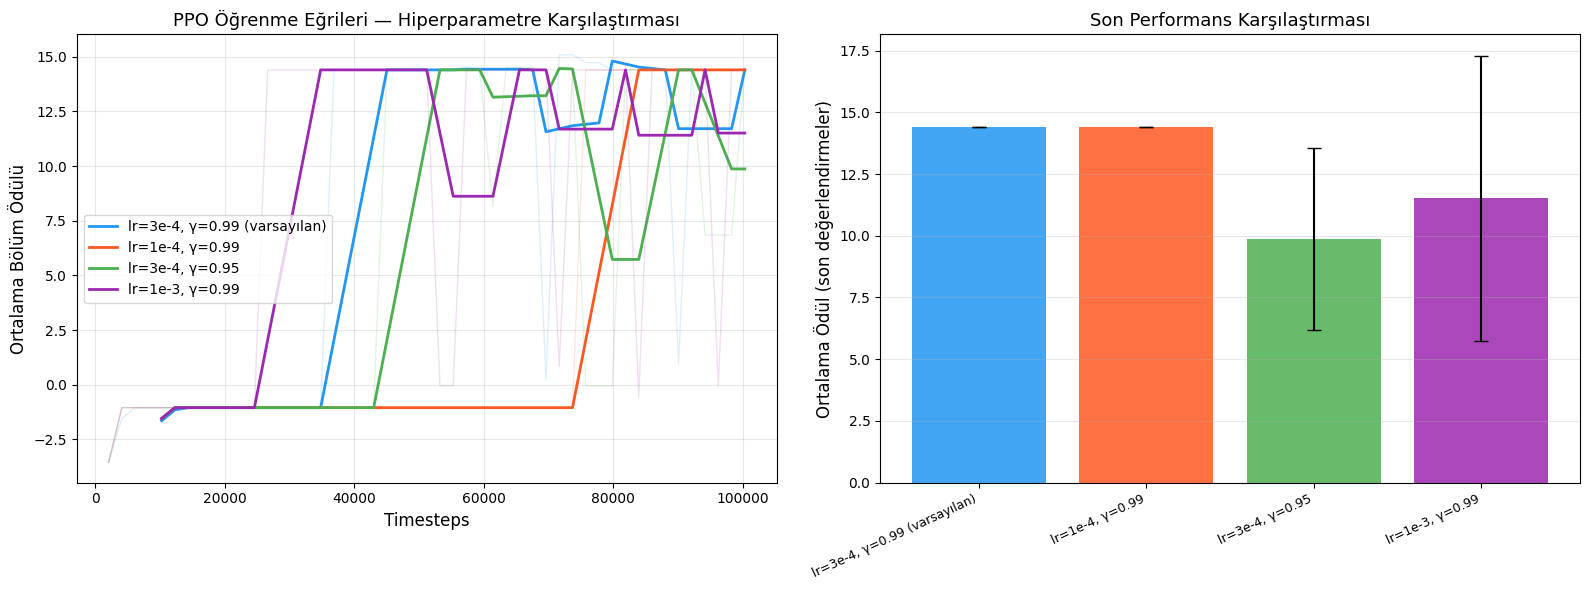

Grafik kaydedildi: ogrenme_egrileri_karsilastirma.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
labels = {
    "deney1_lr3e4_g099": "lr=3e-4, γ=0.99 (varsayılan)",
    "deney2_lr1e4_g099": "lr=1e-4, γ=0.99",
    "deney3_lr3e4_g095": "lr=3e-4, γ=0.95",
    "deney4_lr1e3_g099": "lr=1e-3, γ=0.99",
}
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafik 1: Öğrenme Eğrileri (düzleştirilmiş) ---
ax1 = axes[0]
for i, (name, log_path) in enumerate(log_paths.items()):
    eval_file = os.path.join(log_path, 'evaluations.npz')
    if os.path.exists(eval_file):
        data = np.load(eval_file)
        timesteps = data['timesteps']
        results = data['results']
        mean_rewards = results.mean(axis=1)

        # Hareketli ortalama (pencere=5) ile düzleştir
        window = min(5, len(mean_rewards))
        if window > 1:
            kernel = np.ones(window) / window
            smoothed = np.convolve(mean_rewards, kernel, mode='valid')
            ts_smooth = timesteps[window-1:]
        else:
            smoothed = mean_rewards
            ts_smooth = timesteps

        ax1.plot(ts_smooth, smoothed, label=labels[name],
                 color=colors[i], linewidth=2)

        # Ham veriyi soluk göster
        ax1.plot(timesteps, mean_rewards, color=colors[i],
                 alpha=0.15, linewidth=1)

ax1.set_xlabel('Timesteps', fontsize=12)
ax1.set_ylabel('Ortalama Bölüm Ödülü', fontsize=12)
ax1.set_title('PPO Öğrenme Eğrileri — Hiperparametre Karşılaştırması', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Grafik 2: Son performans bar chart ---
ax2 = axes[1]
final_means = []
final_stds = []
exp_labels = []
for i, (name, log_path) in enumerate(log_paths.items()):
    eval_file = os.path.join(log_path, 'evaluations.npz')
    if os.path.exists(eval_file):
        data = np.load(eval_file)
        results = data['results']
        last_results = results[-5:].flatten()  # son 5 değerlendirme
        final_means.append(last_results.mean())
        final_stds.append(last_results.std())
        exp_labels.append(labels[name])

bars = ax2.bar(range(len(final_means)), final_means, yerr=final_stds,
               color=colors[:len(final_means)], capsize=5, alpha=0.85)
ax2.set_xticks(range(len(exp_labels)))
ax2.set_xticklabels(exp_labels, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('Ortalama Ödül (son değerlendirmeler)', fontsize=12)
ax2.set_title('Son Performans Karşılaştırması', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ogrenme_egrileri_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: ogrenme_egrileri_karsilastirma.png")

## 9. Son 100 Bölüm Başarı Oranı Testi

In [9]:
def evaluate_model(model, num_episodes=100):
    """Eğitilmiş modeli test eder, başarı oranı ve ortalama ödül döndürür."""
    env = make_env()
    successes = 0
    total_rewards = []

    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False
        ep_reward = 0
        steps = 0
        while not done and steps < 300:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_reward += reward
            steps += 1
            if terminated:
                successes += 1

        total_rewards.append(ep_reward)

    env.close()
    return successes / num_episodes, np.mean(total_rewards), np.std(total_rewards)


print(f"{'Deney':<35} {'Başarı %':<12} {'Ort. Ödül':<15} {'Std':<10}")
print("-" * 72)

results_summary = {}
for name, model in models.items():
    success_rate, mean_rew, std_rew = evaluate_model(model, num_episodes=100)
    results_summary[name] = {
        'success_rate': success_rate,
        'mean_reward': mean_rew,
        'std_reward': std_rew
    }
    print(f"{labels[name]:<35} {success_rate*100:>6.1f}%    {mean_rew:>10.2f}     {std_rew:>8.2f}")

Deney                               Başarı %     Ort. Ödül       Std       
------------------------------------------------------------------------
lr=3e-4, γ=0.99 (varsayılan)         100.0%         14.40         0.00
lr=1e-4, γ=0.99                      100.0%         14.40         0.00
lr=3e-4, γ=0.95                      100.0%         14.39         0.00
lr=1e-3, γ=0.99                      100.0%         14.40         0.00


## 10. Eğitilmiş Modeli Test Etme ve Video Kaydetme

In [10]:
from stable_baselines3.common.vec_env import VecVideoRecorder, DummyVecEnv

def record_video(model, video_name='rl_navigation', video_folder='videos/'):
    os.makedirs(video_folder, exist_ok=True)

    def _make():
        base = gym.make('MiniGrid-Empty-8x8-v0', render_mode='rgb_array')
        base = FullyObsWrapper(base)
        base = CustomRewardWrapper(base)
        base = FlattenObsWrapper(base)
        return base

    vec_env = DummyVecEnv([_make])
    vec_env = VecVideoRecorder(
        vec_env,
        video_folder,
        record_video_trigger=lambda x: x == 0,
        video_length=500,
        name_prefix=video_name
    )

    obs = vec_env.reset()
    for _ in range(500):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, dones, _ = vec_env.step(action)
        if dones[0]:
            obs = vec_env.reset()
    vec_env.close()
    print(f"Video '{video_folder}' klasörüne kaydedildi.")

# En iyi deneyin modeliyle video kaydet
best_exp = max(results_summary, key=lambda k: results_summary[k]['success_rate'])
print(f"En iyi deney: {labels[best_exp]}")
record_video(models[best_exp], video_name=f'best_{best_exp}')

En iyi deney: lr=3e-4, γ=0.99 (varsayılan)
Saving video to /content/videos/best_deney1_lr3e4_g099-step-0-to-step-500.mp4


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /content/videos/best_deney1_lr3e4_g099-step-0-to-step-500.mp4.
Moviepy - Writing video /content/videos/best_deney1_lr3e4_g099-step-0-to-step-500.mp4



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Moviepy - Done !
Moviepy - video ready /content/videos/best_deney1_lr3e4_g099-step-0-to-step-500.mp4
Video 'videos/' klasörüne kaydedildi.


## 11. Özet Sonuç Tablosu

In [17]:
import pandas as pd

rows = []
for name in experiments:
    cfg = experiments[name]
    res = results_summary.get(name, {})
    rows.append({
        'Deney': labels[name],
        'Learning Rate': cfg['learning_rate'],
        'Gamma': cfg['gamma'],
        'Başarı (%)': f"{res.get('success_rate', 0)*100:.1f}",
        'Ort. Ödül': f"{res.get('mean_reward', 0):.2f}",
        'Std': f"{res.get('std_reward', 0):.2f}",
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))


                       Deney  Learning Rate  Gamma Başarı (%) Ort. Ödül  Std
lr=3e-4, γ=0.99 (varsayılan)         0.0003   0.99      100.0     14.40 0.00
             lr=1e-4, γ=0.99         0.0001   0.99      100.0     14.40 0.00
             lr=3e-4, γ=0.95         0.0003   0.95      100.0     14.39 0.00
             lr=1e-3, γ=0.99         0.0010   0.99      100.0     14.40 0.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12. Google Drive'a Kaydetme

In [18]:
# Google Drive'a kaydet
from google.colab import drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/Colab Notebooks/yzr502'
!mkdir -p "{drive_path}"
!cp -r logs/ "{drive_path}/"
!cp -r videos/ "{drive_path}/"
!cp ogrenme_egrileri_karsilastirma.png "{drive_path}/"

print("Kaydedilen dosyalar:")
for name in models:
    path = f"./logs/{name}/{name}_model.zip"
    if os.path.exists(path):
        print(f"  ✓ {path}")
best_path = f"./logs/{best_exp}/best_model/best_model.zip"
if os.path.exists(best_path):
    print(f"  ★ {best_path} (en iyi model)")
print(f"  ✓ ogrenme_egrileri_karsilastirma.png")
print(f"  ✓ videos/ klasörü")
print(f"\nTüm dosyalar Drive'a kaydedildi: {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kaydedilen dosyalar:
  ✓ ./logs/deney1_lr3e4_g099/deney1_lr3e4_g099_model.zip
  ✓ ./logs/deney2_lr1e4_g099/deney2_lr1e4_g099_model.zip
  ✓ ./logs/deney3_lr3e4_g095/deney3_lr3e4_g095_model.zip
  ✓ ./logs/deney4_lr1e3_g099/deney4_lr1e3_g099_model.zip
  ★ ./logs/deney1_lr3e4_g099/best_model/best_model.zip (en iyi model)
  ✓ ogrenme_egrileri_karsilastirma.png
  ✓ videos/ klasörü

Tüm dosyalar Drive'a kaydedildi: /content/drive/MyDrive/Colab Notebooks/yzr502


In [15]:
import shutil

drive_path = '/content/drive/MyDrive/Colab Notebooks/yzr502'

# Model, grafik ve videoları Drive'a kopyala
!cp -r logs/ "{drive_path}/"
!cp -r videos/ "{drive_path}/"
!cp ogrenme_egrileri_karsilastirma.png "{drive_path}/"

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
